[Материалы по теме](https://github.com/netology-ds-team/DLL/tree/main/DLL-materials "Учебные блокноты с ГидХаба")

In [ ]:
import torch, pandas as pd, numpy as np, time
import matplotlib.pyplot as plt

##1) Скачайте тренировочную и тестовою часть датасета Fashion MNIST

In [ ]:
# импорт torchvision
import torchvision as tv

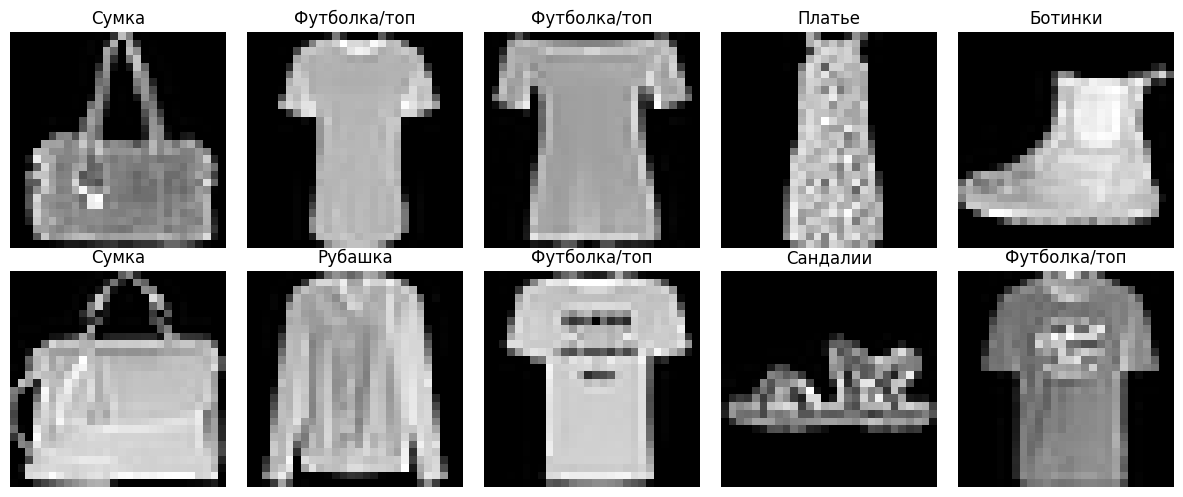

In [ ]:
from torchvision import datasets
import random

# Загрузка FashionMNIST без преобразований
fashion_mnist = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=None  # Без преобразований
)

# Названия классов
class_names = ['Футболка/топ', 'Брюки', 'Свитер', 'Платье', 'Куртка',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

# 10 случайных индексов
random_indices = random.sample(range(len(fashion_mnist)), 10)

# сетка для отображения изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Отображение выбранных изображений
for i, idx in enumerate(random_indices):
    img, label = fashion_mnist[idx]
    # Преобразуем PIL изображение в массив numpy
    img_np = np.array(img)

    # Отображение изображения
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"{class_names[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_dataset = tv.datasets.FashionMNIST('.', train=True, transform=tv.transforms.ToTensor(), download=True)
test_dataset = tv.datasets.FashionMNIST('.', train=False, transform=tv.transforms.ToTensor(), download=True)

In [ ]:
train_Loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_Loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

In [ ]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([256, 1, 28, 28])
Размер одного изображения: torch.Size([1, 28, 28])
Общее количество батчей: 235
Общее количество изображений в датасете: 60000



##2) Постройте модель, выбрав стартовую архитектуру

In [ ]:
model_1 = torch.nn.Sequential(
    torch.nn.Flatten(),        # Принимает 784 входных значения (выпрямляет входные данные в одномерный вектор т.к изображение 28*28 = )
    torch.nn.Linear(784, 256), # создаем полносвязный линейный  слой из 256 нейронов (каждый из 256 нейронов имеет 784 веса (по одному для каждого входного пикселя)). Происходит уменьшение размерности с 784 до 256
    torch.nn.ReLU(),           # функция активации (). Добавляет в сеть нелинейность. Обрабатывает выходы предыдущего слоя, пропуская только положительные значения и заменяя отрицательные нулями.
    torch.nn.Linear(256, 10)   # Принимает полученные после применения функции активации 256 значений и создается слой из 10 нейронов (классы)
)

In [ ]:
# Фнкция потерь. Она автоматически применяет softmax к выходам модели (не нужно делать это отдельно)
loss = torch.nn.CrossEntropyLoss()

In [ ]:
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [ ]:
# ФУНКЦИЯ ОБУЧЕНИЯ МОДЕЛИ
def train_model(model, optimizer_, num_epochs=10): # число эпох по умолчании = 10
    for ep in range(num_epochs):
        train_iters, train_passed  = 0, 0
        train_loss, train_acc = 0., 0.
        start=time.time()

        model.train()
        for X, y in train_Loader:
            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        test_iters, test_passed  = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        for X, y in test_Loader:
            y_pred = model(X)
            l = loss(y_pred, y)
            test_loss += l.item()
            test_acc += (y_pred.argmax(dim=1) == y).sum().item()
            test_iters += 1
            test_passed += len(X)

        print("ep: {}, taked: {:.3f}, train_loss: {}, train_acc: {}, test_loss: {}, test accuracy: {}".format(
            ep, time.time() - start, train_loss / train_iters, train_acc / train_passed,
            test_loss / test_iters, test_acc / test_passed)
        )

## 3) Обучите модель и сверьте качество на тестовой части с заданным порогом

In [ ]:
trainer_1 = optimizer(model=model_1)

In [ ]:
train_model(model=model_1, optimizer_=trainer_1)

ep: 0, taked: 8.277, train_loss: 0.5504230661595121, train_acc: 0.8062833333333334, test_loss: 0.45159805864095687, test accuracy: 0.8317
ep: 1, taked: 7.497, train_loss: 0.3769812746250883, train_acc: 0.8621666666666666, test_loss: 0.4165745947510004, test accuracy: 0.8471
ep: 2, taked: 7.520, train_loss: 0.34653129444477404, train_acc: 0.8735833333333334, test_loss: 0.4041630908846855, test accuracy: 0.8546
ep: 3, taked: 8.492, train_loss: 0.3261862525914578, train_acc: 0.88085, test_loss: 0.37971269339323044, test accuracy: 0.8667
ep: 4, taked: 7.033, train_loss: 0.3146956554752715, train_acc: 0.8827666666666667, test_loss: 0.38906456902623177, test accuracy: 0.8589
ep: 5, taked: 8.452, train_loss: 0.3018044429256561, train_acc: 0.8890833333333333, test_loss: 0.3783645033836365, test accuracy: 0.8677
ep: 6, taked: 8.078, train_loss: 0.29423610409523576, train_acc: 0.8915166666666666, test_loss: 0.4017638936638832, test accuracy: 0.8605
ep: 7, taked: 7.570, train_loss: 0.288780751570

## 4) Изменяйте архитектуру модели пока качество на тестовой части не будет выше порога. Вариации архитектуры можно реализовать через изменение количества слоёв, количества нейронов в слоях и использование регуляризации. Можно использовать различные оптимизаторы.

In [ ]:
# 2.) добавил слой + батчнормализация
model_2 = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 512),
    torch.nn.ReLU(),
    torch.nn.BatchNorm1d(512),
    torch.nn.Linear(512, 256),
    torch.nn.ReLU(),
    torch.nn.BatchNorm1d(256),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.BatchNorm1d(128),
    torch.nn.Linear(128, 10)
)

In [ ]:
trainer_2 = optimizer(model=model_2, lr=0.001)

In [ ]:
train_model(model=model_2, optimizer_=trainer_2, num_epochs=30)

ep: 0, taked: 12.158, train_loss: 0.43785127857898143, train_acc: 0.8439, test_loss: 0.39624123759567736, test accuracy: 0.8558
ep: 1, taked: 12.091, train_loss: 0.339314005095908, train_acc: 0.8757, test_loss: 0.3939521050080657, test accuracy: 0.8558
ep: 2, taked: 12.046, train_loss: 0.3083292117144199, train_acc: 0.8862833333333333, test_loss: 0.3622995249927044, test accuracy: 0.8666
ep: 3, taked: 12.081, train_loss: 0.28601063198231635, train_acc: 0.8927833333333334, test_loss: 0.3714763672091067, test accuracy: 0.8626
ep: 4, taked: 12.074, train_loss: 0.2729554459135583, train_acc: 0.8982333333333333, test_loss: 0.36625068746507167, test accuracy: 0.8664
ep: 5, taked: 12.223, train_loss: 0.2560239669490368, train_acc: 0.9051166666666667, test_loss: 0.35878091026097536, test accuracy: 0.8715
ep: 6, taked: 12.596, train_loss: 0.24132641585583384, train_acc: 0.90945, test_loss: 0.34066667035222054, test accuracy: 0.8787
ep: 7, taked: 12.638, train_loss: 0.2310394194531948, train_acc